# Notebook 1: Label Construction for 30-Day Hospital Readmission (Long-Stay Cohort)

## Objective
Create binary labels (Y=1 if readmitted, Y=0 otherwise) for predicting 30-day hospital readmissions in long-stay patients (LOS ≥15 days) using MIMIC-IV admissions data.

## Input Data
- `admissions.csv` - Hospital admission records from MIMIC-IV core (546,028 admissions)
- `patients.csv` - Patient demographics for age and gender

## Process
1. **Load data** - Import admissions and merge with patient demographics for age calculation
2. **Calculate age at admission** - age_at_admit = anchor_age + (admit_year - anchor_year)
3. **Calculate length of stay** - los_days = (dischtime - admittime) in days
4. **Exclusion criteria**:
   - Remove in-hospital deaths (hospital_expire_flag == 1)
   - Remove transfers to hospice or against medical advice
   - **Filter to LOS ≥15 days** (long-stay patients with higher complexity)
   - Remove admissions with missing age
5. **Label creation** - For each discharge, check if same patient readmitted within 30 days
6. **Column standardization** - Rename to match partner's convention: readmitted_30day → readmitted_within_window, los_days → length_of_stay_days

## Output
- `labeled_admissions_30day_readmission.csv` (~50-60K admissions after LOS ≥15 filter)
- Contains: hadm_id, subject_id, age_at_admit, gender, demographics, length_of_stay_days, and readmitted_within_window label
- Expected readmission rate: ~22-25% (higher than general 19.6% due to long-stay complexity)

## Clinical Rationale
Long-stay patients (≥15 days) represent complex cases with higher comorbidity burden, severe illness, and elevated readmission risk, making them high-value targets for predictive interventions.

## Next Step
Notebook 2 will link these labeled admissions to clinical discharge notes and chest X-ray reports.

In [20]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# Import required libraries
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

print("Imported libraries.")

Imported libraries.


In [22]:
# Define paths
DATA_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/data')
OUTPUT_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/output')

# Create output directory if it doesn't exist
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

# Check what files we have
print("\n" + "-"*60)
print("Available data files:")
print("-"*60)

if DATA_DIR.exists():
    files = list(DATA_DIR.glob('*.csv'))
    if len(files) == 0:
        print("No .csv files found in data directory")
    else:
        for file in sorted(files):
            size_mb = file.stat().st_size / (1024 * 1024)
            print(f"  {file.name:<30} {size_mb:>8.1f} MB")
else:
    print("ERROR: Data directory not found. Please check the path.")

Data directory: /content/drive/MyDrive/MIDS/w266/Final Project/data
Output directory: /content/drive/MyDrive/MIDS/w266/Final Project/output

------------------------------------------------------------
Available data files:
------------------------------------------------------------
  admissions.csv                     89.8 MB
  clinical_event_timestamp.csv      835.2 MB
  d_icd_diagnoses.csv                 8.7 MB
  d_icd_procedures.csv                7.1 MB
  d_labitems.csv                      0.1 MB
  diagnoses_icd.csv                 173.0 MB
  discharge.csv                    3365.3 MB
  drgcodes.csv                       52.2 MB
  labevents.csv                   17550.3 MB
  microbiologyevents.csv            867.1 MB
  patients.csv                       11.5 MB
  prescriptions.csv                3326.6 MB
  procedures_icd.csv                 32.7 MB
  radiology.csv                    2738.2 MB
  radiology_detail.csv              292.3 MB
  services.csv                       24.

In [23]:
# Load admissions data
print("Loading admissions.csv...")
admissions = pd.read_csv(DATA_DIR / 'admissions.csv')

print(f"Loaded {len(admissions):,} hospital admissions")
print(f"\nDataset shape: {admissions.shape}")
print(f"\nColumns: {admissions.columns.tolist()}")

Loading admissions.csv...
Loaded 546,028 hospital admissions

Dataset shape: (546028, 16)

Columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']


In [24]:
# Load patients table to get age
print("\nLoading patients for age calculation...")
patients_df = pd.read_csv(DATA_DIR / 'patients.csv')

print(f"Total patients: {len(patients_df):,}")
print(f"Patients columns: {patients_df.columns.tolist()}")

# Merge with admissions to get anchor_year and anchor_age
admissions = admissions.merge(
    patients_df[['subject_id', 'anchor_age', 'anchor_year', 'gender']],
    on='subject_id',
    how='left'
)

print(f"Merged with patients data")


Loading patients for age calculation...
Total patients: 364,627
Patients columns: ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']
Merged with patients data


In [25]:
# Display first few rows
print("\nFirst 5 admissions:")
admissions.head()


First 5 admissions:


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,anchor_age,anchor_year,gender
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,52,2180,F
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0,52,2180,F
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0,52,2180,F
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,52,2180,F
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0,19,2160,F


In [26]:
# Check data types and missing values
print("\nData Info:")
admissions.info()


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546028 entries, 0 to 546027
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   subject_id            546028 non-null  int64 
 1   hadm_id               546028 non-null  int64 
 2   admittime             546028 non-null  object
 3   dischtime             546028 non-null  object
 4   deathtime             11790 non-null   object
 5   admission_type        546028 non-null  object
 6   admit_provider_id     546024 non-null  object
 7   admission_location    546027 non-null  object
 8   discharge_location    396210 non-null  object
 9   insurance             536673 non-null  object
 10  language              545253 non-null  object
 11  marital_status        532409 non-null  object
 12  race                  546028 non-null  object
 13  edregtime             379240 non-null  object
 14  edouttime             379240 non-null  object
 15  hospi

In [27]:
# Load patients data
print("Loading patients.csv...")
patients = pd.read_csv(DATA_DIR / 'patients.csv')

print(f"Loaded {len(patients):,} unique patients")
print(f"\nColumns: {patients.columns.tolist()}")
print("\nFirst 5 patients:")
patients.head()

Loading patients.csv...
Loaded 364,627 unique patients

Columns: ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']

First 5 patients:


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [28]:
# Convert datetime columns
print("Converting datetime columns...")

# Admissions dates
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])
admissions['deathtime'] = pd.to_datetime(admissions['deathtime'])
admissions['edregtime'] = pd.to_datetime(admissions['edregtime'])
admissions['edouttime'] = pd.to_datetime(admissions['edouttime'])

# Patient death date
patients['dod'] = pd.to_datetime(patients['dod'])

print("Datetime conversion complete")

# Calculate length of stay
admissions['los_days'] = (admissions['dischtime'] - admissions['admittime']).dt.total_seconds() / (24 * 3600)

print(f"\nLength of Stay Statistics:")
print(admissions['los_days'].describe())

Converting datetime columns...
Datetime conversion complete

Length of Stay Statistics:
count    546028.000000
mean          4.761742
std           7.207125
min          -0.945139
25%           1.128472
50%           2.818056
75%           5.621528
max         515.562500
Name: los_days, dtype: float64


In [29]:
# Calculate age at admission
print("\nCalculating age at admission...")

# Extract year from admittime
admissions['admit_year'] = pd.to_datetime(admissions['admittime']).dt.year

# Calculate age at admission
# anchor_age is the patient's age in anchor_year
# age_at_admit = anchor_age + (admit_year - anchor_year)
admissions['age_at_admit'] = (
    admissions['anchor_age'] +
    (admissions['admit_year'] - admissions['anchor_year'])
)

print(f"Age statistics:")
print(f"  Mean age: {admissions['age_at_admit'].mean():.1f} years")
print(f"  Median age: {admissions['age_at_admit'].median():.1f} years")
print(f"  Min age: {admissions['age_at_admit'].min():.0f} years")
print(f"  Max age: {admissions['age_at_admit'].max():.0f} years")

# Check for missing ages
missing_age = admissions['age_at_admit'].isna().sum()
if missing_age > 0:
    print(f"\n⚠ WARNING: {missing_age:,} admissions have missing age")
    print("Removing admissions with missing age...")
    admissions = admissions[admissions['age_at_admit'].notna()].copy()
    print(f"Remaining admissions: {len(admissions):,}")


Calculating age at admission...
Age statistics:
  Mean age: 59.2 years
  Median age: 61.0 years
  Min age: 18 years
  Max age: 106 years


In [30]:
# Basic statistics
print("ADMISSION STATISTICS")
print("="*60)

print(f"\nTotal admissions: {len(admissions):,}")
print(f"Unique patients: {admissions['subject_id'].nunique():,}")
print(f"\nAdmissions per patient:")
admissions_per_patient = admissions.groupby('subject_id').size()
print(admissions_per_patient.describe())

print(f"\nAdmission Types:")
print(admissions['admission_type'].value_counts())

print(f"\nDischarge Locations:")
print(admissions['discharge_location'].value_counts())

ADMISSION STATISTICS

Total admissions: 546,028
Unique patients: 223,452

Admissions per patient:
count    223452.000000
mean          2.443603
std           3.574410
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max         238.000000
dtype: float64

Admission Types:
admission_type
EW EMER.                       177459
EU OBSERVATION                 119456
OBSERVATION ADMIT               84437
URGENT                          54929
SURGICAL SAME DAY ADMISSION     42898
DIRECT OBSERVATION              24551
DIRECT EMER.                    21973
ELECTIVE                        13130
AMBULATORY OBSERVATION           7195
Name: count, dtype: int64

Discharge Locations:
discharge_location
HOME                            194204
HOME HEALTH CARE                 99305
SKILLED NURSING FACILITY         52657
REHAB                            13845
DIED                             11721
CHRONIC/LONG TERM ACUTE CARE      8125
HOSPICE                    

In [31]:
# Check for in-hospital deaths
print("\nDeath Information:")
print("-"*60)
print(f"Admissions with in-hospital death (deathtime not null): {admissions['deathtime'].notna().sum():,}")
print(f"Admissions with hospital_expire_flag=1: {(admissions['hospital_expire_flag'] == 1).sum():,}")

# These should match
death_mismatch = (admissions['deathtime'].notna() != (admissions['hospital_expire_flag'] == 1)).sum()
print(f"\nMismatch between deathtime and hospital_expire_flag: {death_mismatch}")


Death Information:
------------------------------------------------------------
Admissions with in-hospital death (deathtime not null): 11,790
Admissions with hospital_expire_flag=1: 11,801

Mismatch between deathtime and hospital_expire_flag: 11


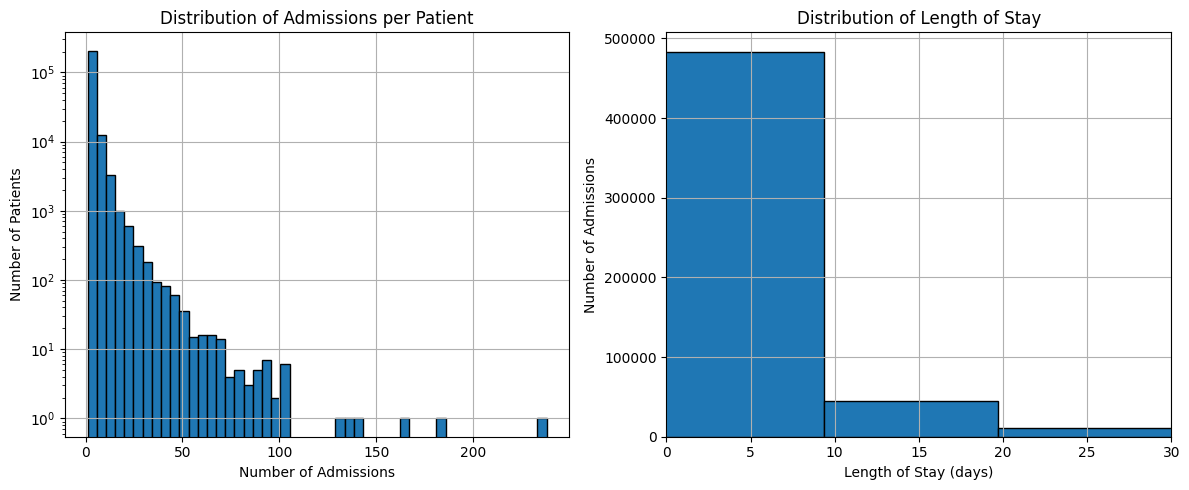

Plot saved to output directory


In [32]:
# Visualize admissions per patient
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
admissions_per_patient.hist(bins=50, edgecolor='black')
plt.xlabel('Number of Admissions')
plt.ylabel('Number of Patients')
plt.title('Distribution of Admissions per Patient')
plt.yscale('log')

plt.subplot(1, 2, 2)
admissions['los_days'].hist(bins=50, edgecolor='black')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Number of Admissions')
plt.title('Distribution of Length of Stay')
plt.xlim(0, 30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'step1_admissions_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to output directory")

In [33]:
# Apply exclusion criteria
print("\nApplying exclusion criteria...")
print(f"Starting with: {len(admissions):,} admissions")

# 1. Exclude deaths during admission
deaths = admissions['hospital_expire_flag'] == 1
print(f"  Deaths during admission: {deaths.sum():,}")
admissions = admissions[~deaths].copy()
print(f"  After excluding deaths: {len(admissions):,}")

# 2. Exclude transfers
transfers = admissions['discharge_location'].isin([
    'DIED', 'HOSPICE', 'AGAINST ADVICE'
])
print(f"  Transfers/hospice/AMA: {transfers.sum():,}")
admissions = admissions[~transfers].copy()
print(f"  After excluding transfers: {len(admissions):,}")

# 3. Filter to long-stay patients (LOS >= 15 days)
print(f"\n  Applying LOS filter (>= 15 days)...")
print(f"  Before LOS filter: {len(admissions):,}")
print(f"  LOS statistics:")
print(f"    Mean: {admissions['los_days'].mean():.1f} days")
print(f"    Median: {admissions['los_days'].median():.1f} days")
print(f"    LOS >= 15: {(admissions['los_days'] >= 15).sum():,}")

admissions = admissions[admissions['los_days'] >= 15].copy()
print(f"  After LOS filter (>= 15 days): {len(admissions):,}")

print(f"\nFinal eligible admissions: {len(admissions):,}")


Applying exclusion criteria...
Starting with: 546,028 admissions
  Deaths during admission: 11,801
  After excluding deaths: 534,227
  Transfers/hospice/AMA: 8,995
  After excluding transfers: 525,232

  Applying LOS filter (>= 15 days)...
  Before LOS filter: 525,232
  LOS statistics:
    Mean: 4.6 days
    Median: 2.8 days
    LOS >= 15: 24,571
  After LOS filter (>= 15 days): 24,571

Final eligible admissions: 24,571


In [34]:
# Sort by patient and admission time
print("\nSorting admissions chronologically...")
index_admissions = admissions.copy()
index_admissions = index_admissions.sort_values(['subject_id', 'admittime']).reset_index(drop=True)

# Create a copy of all admissions sorted for readmission checking
all_admissions_sorted = admissions[admissions['hospital_expire_flag'] == 0].sort_values(
    ['subject_id', 'admittime']
).reset_index(drop=True)

print(f"Sorted {len(index_admissions):,} index admissions")
print(f"Sorted {len(all_admissions_sorted):,} total admissions for checking readmissions")


Sorting admissions chronologically...
Sorted 24,571 index admissions
Sorted 24,571 total admissions for checking readmissions


In [35]:
# For each index admission, find if there's a readmission within 30 days
print("\nIdentifying 30-day readmissions...")

# Initialize label column
index_admissions['readmitted_30day'] = 0
index_admissions['days_to_readmission'] = np.nan
index_admissions['readmission_hadm_id'] = np.nan

# Group admissions by patient for faster lookup
patient_admissions = all_admissions_sorted.groupby('subject_id')

# Counter for progress
total = len(index_admissions)
readmission_count = 0

for idx, row in index_admissions.iterrows():
    # Progress indicator every 10,000 rows
    if (idx + 1) % 10000 == 0:
        print(f"  Processed {idx + 1:,} / {total:,} ({(idx+1)/total*100:.1f}%)")

    subject_id = row['subject_id']
    discharge_time = row['dischtime']
    current_hadm_id = row['hadm_id']

    # Get all admissions for this patient
    if subject_id not in patient_admissions.groups:
        continue

    patient_admits = patient_admissions.get_group(subject_id)

    # Find admissions that start after this discharge
    future_admits = patient_admits[
        (patient_admits['admittime'] > discharge_time) &
        (patient_admits['hadm_id'] != current_hadm_id)
    ]

    if len(future_admits) > 0:
        # Get the next admission
        next_admit = future_admits.iloc[0]
        days_to_next = (next_admit['admittime'] - discharge_time).total_seconds() / (24 * 3600)

        # Check if within 30 days
        if days_to_next <= 30:
            index_admissions.loc[idx, 'readmitted_30day'] = 1
            index_admissions.loc[idx, 'days_to_readmission'] = days_to_next
            index_admissions.loc[idx, 'readmission_hadm_id'] = next_admit['hadm_id']
            readmission_count += 1

print(f"\nLabel creation complete")
print(f"\nREADMISSION STATISTICS:")
print("-"*60)
print(f"  Total index admissions: {len(index_admissions):,}")
print(f"  Readmitted within 30 days: {readmission_count:,} ({readmission_count/len(index_admissions)*100:.2f}%)")
print(f"  Not readmitted: {len(index_admissions) - readmission_count:,} ({(len(index_admissions) - readmission_count)/len(index_admissions)*100:.2f}%)")


Identifying 30-day readmissions...
  Processed 10,000 / 24,571 (40.7%)
  Processed 20,000 / 24,571 (81.4%)

Label creation complete

READMISSION STATISTICS:
------------------------------------------------------------
  Total index admissions: 24,571
  Readmitted within 30 days: 1,414 (5.75%)
  Not readmitted: 23,157 (94.25%)



LABEL DISTRIBUTION:
readmitted_30day
0    23157
1     1414
Name: count, dtype: int64

Days to Readmission (for readmitted cases):
count    1414.000000
mean       11.905818
std         8.521037
min         0.000694
25%         4.267361
50%        10.692014
75%        18.901042
max        29.881944
Name: days_to_readmission, dtype: float64


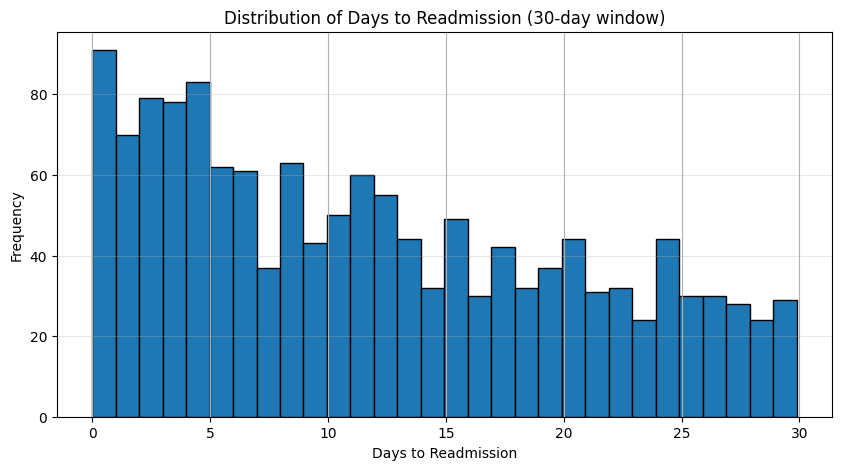

In [36]:
# Analyze the labels
print("\nLABEL DISTRIBUTION:")
print(index_admissions['readmitted_30day'].value_counts())

print("\nDays to Readmission (for readmitted cases):")
print(index_admissions[index_admissions['readmitted_30day'] == 1]['days_to_readmission'].describe())

# Plot distribution of days to readmission
plt.figure(figsize=(10, 5))
index_admissions[index_admissions['readmitted_30day'] == 1]['days_to_readmission'].hist(bins=30, edgecolor='black')
plt.xlabel('Days to Readmission')
plt.ylabel('Frequency')
plt.title('Distribution of Days to Readmission (30-day window)')
plt.grid(axis='y', alpha=0.3)
plt.savefig(OUTPUT_DIR / 'step1_days_to_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Rename columns to match partner's naming convention
print("\nRenaming columns to match standard naming...")

index_admissions = index_admissions.rename(columns={
    'readmitted_30day': 'readmitted_within_window',
    'days_to_readmission': 'readmission_gap_in_days',
    'los_days': 'length_of_stay_days'
})

# Save labeled admissions
output_file = OUTPUT_DIR / 'labeled_admissions_30day_readmission.csv'

# Select columns to save (match partner's expected columns)
columns_to_save = [
    'subject_id', 'hadm_id',
    'admittime', 'dischtime',
    'admission_type', 'admission_location', 'discharge_location',
    'insurance', 'language', 'marital_status', 'race',
    'length_of_stay_days',
    'age_at_admit', 'gender',
    'readmitted_within_window', 'readmission_gap_in_days', 'readmission_hadm_id'
]

index_admissions[columns_to_save].to_csv(output_file, index=False)

print(f"\nSaved to: {output_file}")
print(f"Final cohort size: {len(index_admissions):,}")
print(f"\nLabel distribution:")
print(index_admissions['readmitted_within_window'].value_counts())
print(f"Readmission rate: {index_admissions['readmitted_within_window'].mean()*100:.2f}%")

print(f"\nAge distribution:")
print(f"  Mean: {index_admissions['age_at_admit'].mean():.1f} years")
print(f"  Median: {index_admissions['age_at_admit'].median():.1f} years")

print(f"\nLOS distribution (filtered to >= 15):")
print(f"  Mean: {index_admissions['length_of_stay_days'].mean():.1f} days")
print(f"  Median: {index_admissions['length_of_stay_days'].median():.1f} days")
print(f"  Min: {index_admissions['length_of_stay_days'].min():.1f} days")
print(f"  Max: {index_admissions['length_of_stay_days'].max():.1f} days")


Renaming columns to match standard naming...

Saved to: /content/drive/MyDrive/MIDS/w266/Final Project/output/labeled_admissions_30day_readmission.csv
Final cohort size: 24,571

Label distribution:
readmitted_within_window
0    23157
1     1414
Name: count, dtype: int64
Readmission rate: 5.75%

Age distribution:
  Mean: 61.3 years
  Median: 63.0 years

LOS distribution (filtered to >= 15):
  Mean: 27.0 days
  Median: 21.8 days
  Min: 15.0 days
  Max: 515.6 days


In [40]:
# Final summary
print("\n" + "="*60)
print("STEP 1 COMPLETE: 30-DAY READMISSION LABELS CREATED")
print("="*60)

print(f"\nTotal labeled admissions: {len(index_admissions):,}")
print(f"Positive cases (readmitted): {(index_admissions['readmitted_within_window'] == 1).sum():,}")
print(f"Negative cases (not readmitted): {(index_admissions['readmitted_within_window'] == 0).sum():,}")
print(f"Class imbalance ratio: {(index_admissions['readmitted_within_window'] == 0).sum() / (index_admissions['readmitted_within_window'] == 1).sum():.2f}:1")
print(f"\nOutput saved to: {output_file}")
print(f"\nReady for Step 2: Link Clinical Notes")


STEP 1 COMPLETE: 30-DAY READMISSION LABELS CREATED

Total labeled admissions: 24,571
Positive cases (readmitted): 1,414
Negative cases (not readmitted): 23,157
Class imbalance ratio: 16.38:1

Output saved to: /content/drive/MyDrive/MIDS/w266/Final Project/output/labeled_admissions_30day_readmission.csv

Ready for Step 2: Link Clinical Notes
